In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.svm import SVC
import time
from time import time

from scipy import linalg
from numpy.linalg import norm
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.metrics import accuracy_score
from collections import Counter

### For Complex dataset

Kept 10 people with most images:
ID 7: Brad Pitt - 120 images
ID 28: Vijay Deverakonda - 115 images
ID 25: Robert Downey Jr - 113 images
ID 17: Hugh Jackman - 112 images
ID 18: Jessica Alba - 108 images
ID 15: Henry Cavill - 106 images
ID 23: Natalie Portman - 105 images
ID 24: Priyanka Chopra - 102 images
ID 16: Hrithik Roshan - 101 images
ID 6: Billie Eilish - 98 images

Original dataset: 2562 images
Limited dataset: 1080 images
===== Data Preparation Results =====
Dataset loaded successfully:
- Total images: 1080
- Number of people: 10
- Image dimension: 64x64 pixels
- Data shape: (1080, 4096)


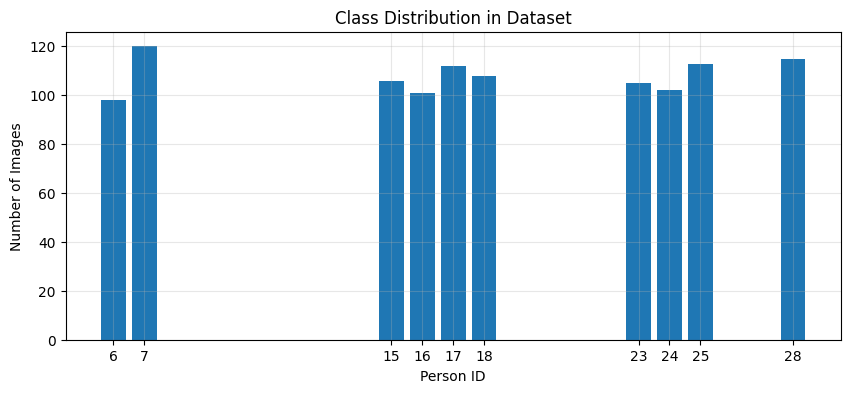

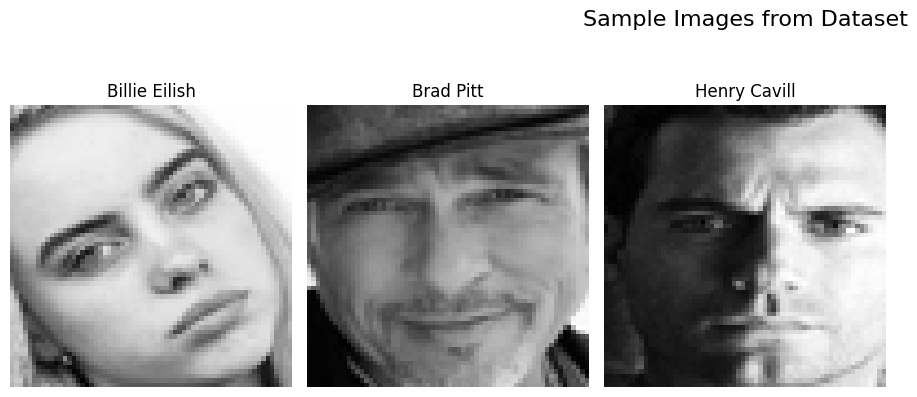


Data split:
- Training set: 980 images
- Test set: 100 images


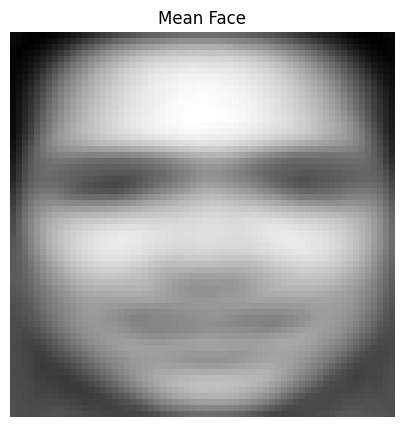

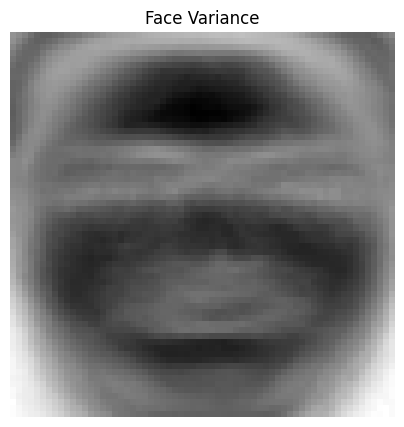

Limited data preparation completed successfully!


In [3]:
# New function to load photos with names in the format n1_n2.jpg,

def load_images_complex(dataset_path, target_size=(64, 64)):
    images = []
    labels = []
    label_dict = {}
    person_names = set()

    # First pass to identify all unique person names
    for img_file in os.listdir(dataset_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            # Extract person name from filename (assuming format: person_name_number.jpg)
            person_name = img_file.split('_')[0]
            person_names.add(person_name)

    # Create label mapping
    for i, name in enumerate(sorted(person_names)):
        label_dict[i] = name

    # Second pass to load images with proper labels
    for img_file in os.listdir(dataset_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            try:
                img_path = os.path.join(dataset_path, img_file)
                person_name = img_file.split('_')[0]

                # Find the label for this person
                person_id = [k for k, v in label_dict.items() if v == person_name][0]
                # Load and process the image
                img = Image.open(img_path).convert('L')  # Convert to grayscale
                img = img.resize(target_size)  # Resize to consistent dimensions
                img_array = np.array(img).flatten()  # Flatten to 1D array

                images.append(img_array)
                labels.append(person_id)
            except Exception as e:
                print(f"Error loading {img_file}: {e}")
    return np.array(images), np.array(labels), label_dict

def preprocess_images(X_train, X_test):
    # Normalize pixel values to [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    X_train = (X_train - np.mean(X_train, axis=1, keepdims=True)) / (np.std(X_train, axis=1, keepdims=True) + 1e-7)
    X_test = (X_test - np.mean(X_test, axis=1, keepdims=True)) / (np.std(X_test, axis=1, keepdims=True) + 1e-7)

    return X_train, X_test

def load_images_orl(dataset_path, target_size=(64, 64)):
    images = []
    labels = []
    label_dict = {}
    person_ids = set()

    # Detect unique person identifiers (n2) in the dataset
    for img_file in os.listdir(dataset_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            try:
                parts = os.path.splitext(img_file)[0].split('_')
                if len(parts) < 2:
                    continue
                person_id = parts[1]  # n2 — person number
                person_ids.add(person_id)
            except Exception as e:
                print(f"Error parsing file name {img_file}: {e}")

    # Create dictionary {label: person_id}
    for i, pid in enumerate(sorted(person_ids)):
        label_dict[i] = pid

    # Load images and assign them to labels
    for img_file in os.listdir(dataset_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            try:
                img_path = os.path.join(dataset_path, img_file)
                parts = os.path.splitext(img_file)[0].split('_')
                if len(parts) < 2:
                    continue
                person_id = parts[1]  # n2

                # Find the corresponding label for this person
                label = [k for k, v in label_dict.items() if v == person_id][0]

                # Load and process the image
                img = Image.open(img_path).convert('L')
                img = img.resize(target_size)
                img_array = np.array(img).flatten()

                images.append(img_array)
                labels.append(label)
            except Exception as e:
                print(f"Error loading {img_file}: {e}")

    return np.array(images), np.array(labels), label_dict

# Split dataset function
def split_dataset(images, labels):
    unique_ids = np.unique(labels)
    X_train, y_train = [], []
    X_test, y_test = [], []

    for uid in unique_ids:
        mask = labels == uid
        person_images = images[mask]
        person_labels = labels[mask]
        X_test.append(person_images[:10])
        y_test.append(person_labels[:10])
        X_train.append(person_images[10:])
        y_train.append(person_labels[10:])

    X_train = np.concatenate(X_train)
    y_train = np.concatenate(y_train)
    X_test = np.concatenate(X_test)
    y_test = np.concatenate(y_test)

    return X_train, y_train, X_test, y_test

def split_dataset_orl(images, labels):
    unique_ids = np.unique(labels)
    X_train, y_train = [], []
    X_test, y_test = [], []

    for uid in unique_ids:
        mask = labels == uid
        person_images = images[mask]
        person_labels = labels[mask]
        X_test.append(person_images[:1])
        y_test.append(person_labels[:1])
        X_train.append(person_images[1:])
        y_train.append(person_labels[1:])

    X_train = np.concatenate(X_train)
    y_train = np.concatenate(y_train)
    X_test = np.concatenate(X_test)
    y_test = np.concatenate(y_test)

    return X_train, y_train, X_test, y_test

# Visualize data preparation
def visualize_data_preparation(X, y):
    print("===== Data Preparation Results =====")

    # 1. Basic dataset statistics
    n_samples = len(X)
    n_classes = len(np.unique(y))
    img_dim = int(np.sqrt(X.shape[1]))

    print(f"Dataset loaded successfully:")
    print(f"- Total images: {n_samples}")
    print(f"- Number of people: {n_classes}")
    print(f"- Image dimension: {img_dim}x{img_dim} pixels")
    print(f"- Data shape: {X.shape}")

    # 2. Show class distribution
    unique_classes, class_counts = np.unique(y, return_counts=True)

    plt.figure(figsize=(10, 4))
    plt.bar(unique_classes, class_counts)
    plt.xlabel("Person ID")
    plt.ylabel("Number of Images")
    plt.title("Class Distribution in Dataset")
    plt.xticks(unique_classes)
    plt.grid(alpha=0.3)
    plt.show()

    # 3. Show sample images from each class
    plt.figure(figsize=(15, 8))
    plt.suptitle("Sample Images from Dataset", fontsize=16)

    for i, class_id in enumerate(unique_classes[:3]):  # Limit to first 3 classes
        class_images = X[y == class_id]
        if len(class_images) > 0:
            plt.subplot(2, 5, i+1)
            plt.imshow(class_images[0].reshape(img_dim, img_dim), cmap='gray')
            plt.title(f"{label_dict[class_id]}" if class_id in label_dict else f"Person {class_id}")
            plt.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

    # 4. Show data splits
    X_train, y_train, X_test, y_test = split_dataset(X, y)

    print("\nData split:")
    print(f"- Training set: {len(X_train)} images")
    print(f"- Test set: {len(X_test)} images")

    # 5. Show mean face
    mean_face = np.mean(X_train, axis=0)
    plt.figure(figsize=(5, 5))
    plt.imshow(mean_face.reshape(img_dim, img_dim), cmap='gray')
    plt.title("Mean Face")
    plt.axis('off')
    plt.show()

    # 6. Show face variance
    std_face = np.std(X_train, axis=0)
    plt.figure(figsize=(5, 5))
    plt.imshow(std_face.reshape(img_dim, img_dim), cmap='gray')
    plt.title("Face Variance")
    plt.axis('off')
    plt.show()

    return X_train, y_train, X_test, y_test

# Limit dataset to top N people by image count
def limit_dataset_to_n_people(X, y, label_dict, n=5):
    # Count images per person
    unique_ids, counts = np.unique(y, return_counts=True)

    # Sort people by number of images (descending)
    sorted_indices = np.argsort(-counts)
    top_n_ids = unique_ids[sorted_indices[:n]]

    # Create mask for selected people
    mask = np.isin(y, top_n_ids)

    # Filter dataset
    X_limited = X[mask]
    y_limited = y[mask]

    # Create new label mapping (keeping original IDs)
    label_dict_limited = {id_: label_dict[id_] for id_ in top_n_ids}

    # Print statistics
    print(f"Kept {n} people with most images:")
    for id_ in top_n_ids:
        count = np.sum(y == id_)
        print(f"ID {id_}: {label_dict[id_]} - {count} images")

    print(f"\nOriginal dataset: {len(X)} images")
    print(f"Limited dataset: {len(X_limited)} images")

    return X_limited, y_limited, label_dict_limited

dataset_path = "Faces"
X, y, label_dict = load_images_complex(dataset_path)

X_limited, y_limited, label_dict_limited = limit_dataset_to_n_people(X, y, label_dict, n=10)
X, y = X_limited, y_limited

X_train, y_train, X_test, y_test = split_dataset_complex(X, y)

try:
    X_train, y_train, X_test, y_test = visualize_data_preparation(X, y)
    print("Limited data preparation completed successfully!")
except Exception as e:
    print(f"Error during data preparation: {e}")

# IMPORTANT: our people will be rows and columns are the photos,
# so [0] is number of people, [1] is number of photos


### For ORL dataset


In [5]:

def norm(v):
    v = np.asarray(v, dtype=float)

    # Обчислення Евклідової норми
    return np.sqrt(np.sum(np.square(v)))

def power_iteration(A, max_iters=1000, tol=1e-10):
    n = A.shape[1]
    b_k = np.random.rand(n)

    for _ in range(max_iters):
        b_k1 = A @ b_k
        b_k1_norm = norm(b_k1)

        if b_k1_norm < tol:
            return 0.0, np.zeros(n)

        b_k = b_k1 / b_k1_norm

    eigenvalue = np.dot(np.conj(b_k).T, np.dot(A, b_k)) / np.dot(np.conj(b_k).T, b_k)
    eigenvector = b_k

    return eigenvalue, eigenvector

def find_eigens(A, max_iters=1000):
    eigenvalues = []
    eigenvectors = []
    A_current = A.astype(float)
    n = A.shape[1]

    for _ in range(n):
        eigval, eigvec = power_iteration(A_current, max_iters)

        if norm(eigvec) < 1e-8 or np.isnan(eigval):
            continue

        eigvec /= norm(eigvec)
        for v in eigenvectors:
            eigvec -= (v @ eigvec) * v

        eigenvalues.append(eigval)
        eigenvectors.append(eigvec)
        A_current -= eigval * np.outer(eigvec, eigvec)

    while len(eigenvalues) < n:
        eigenvalues.append(0.0)
        eigenvectors.append(np.zeros(n))

    return np.array(eigenvalues), np.array(eigenvectors)


In [6]:
def pca(X, n_components, regularization=1e-6):
    mean_face = np.mean(X, axis=0)
    X_centered = X - mean_face
    n_samples = X_centered.shape[0]
    if X_centered.shape[1] > n_samples:
        cov_small = np.dot(X_centered, X_centered.T) / (n_samples - 1)
        cov_small += np.eye(cov_small.shape[0]) * regularization

        eigenvalues_small, eigenvectors_small = find_eigens(cov_small)

        idx = np.argsort(eigenvalues_small)[::-1]
        eigenvalues_small = eigenvalues_small[idx]
        eigenvectors_small = eigenvectors_small[idx]

        eigenvectors = np.dot(X_centered.T, eigenvectors_small)

        for i in range(eigenvectors.shape[1]):
            vec_norm = norm(eigenvectors[:, i])
            if vec_norm > 1e-8:
                eigenvectors[:, i] /= vec_norm
            else:
                eigenvectors[:, i] = np.zeros_like(eigenvectors[:, i])

        eigenvalues = eigenvalues_small
    else:
        cov = np.dot(X_centered.T, X_centered) / (n_samples - 1)
        cov += np.eye(cov.shape[0]) * regularization

        eigenvalues, eigenvectors = find_eigens(cov)

        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[idx]

    max_components = min(n_components, X.shape[0], X.shape[1])
    eigenvectors = eigenvectors[:, :max_components]
    eigenvalues = eigenvalues[:max_components]

    projected = np.dot(X_centered, eigenvectors)

    total_var = np.sum(eigenvalues)
    explained_variance = eigenvalues / total_var if total_var > 0 else np.zeros_like(eigenvalues)

    return projected, eigenvectors, eigenvalues, mean_face, explained_variance
# --- PCA ---
X_train_projected, eigenvectors, eigenvalues, mean_face, explained_variance = pca(X_train, 58)
# --- Project test set ---
X_test_centered = X_test - mean_face
projected_test = np.dot(X_test_centered, eigenvectors)

# --- Distances: test vs train ---
dists = np.linalg.norm(X_train_projected[:, np.newaxis, :] - projected_test[np.newaxis, :, :], axis=2)
min_dists = np.min(dists, axis=0)
nearest_indices = np.argmin(dists, axis=0)

# --- Create result dictionary --- 
nearest_classes = y_train[nearest_indices]
result_dict = {i: nearest_classes[i] for i in range(len(projected_test))}

# --- Predict using the dictionary ---
y_pred = np.array([result_dict[i] for i in range(len(y_test))])

# --- Evaluate ---
accuracy = np.mean(y_pred == y_test)

# Results
print(f"Accuracy: {accuracy:.4f}")

# --- Debug ---
for i, (pred, true, dist) in enumerate(zip(y_pred, y_test, min_dists)):
    if pred != true:
        print(f"Wrong: test[{i}] predicted {pred}, true {true}, dist {dist:.2f}")



Accuracy: 0.3200
Wrong: test[1] predicted 25, true 6, dist 2299.76
Wrong: test[2] predicted 15, true 6, dist 2599.20
Wrong: test[3] predicted 7, true 6, dist 2262.63
Wrong: test[4] predicted 15, true 6, dist 2312.89
Wrong: test[5] predicted 18, true 6, dist 2524.49
Wrong: test[6] predicted 7, true 6, dist 4036.29
Wrong: test[10] predicted 28, true 7, dist 2679.97
Wrong: test[11] predicted 15, true 7, dist 2577.67
Wrong: test[12] predicted 6, true 7, dist 2291.38
Wrong: test[14] predicted 25, true 7, dist 2328.89
Wrong: test[15] predicted 15, true 7, dist 1948.98
Wrong: test[16] predicted 15, true 7, dist 2730.10
Wrong: test[17] predicted 25, true 7, dist 2682.64
Wrong: test[19] predicted 25, true 7, dist 1388.76
Wrong: test[20] predicted 16, true 15, dist 3833.83
Wrong: test[21] predicted 17, true 15, dist 1680.95
Wrong: test[22] predicted 7, true 15, dist 2062.68
Wrong: test[23] predicted 17, true 15, dist 2284.47
Wrong: test[24] predicted 6, true 15, dist 2211.67
Wrong: test[25] pred

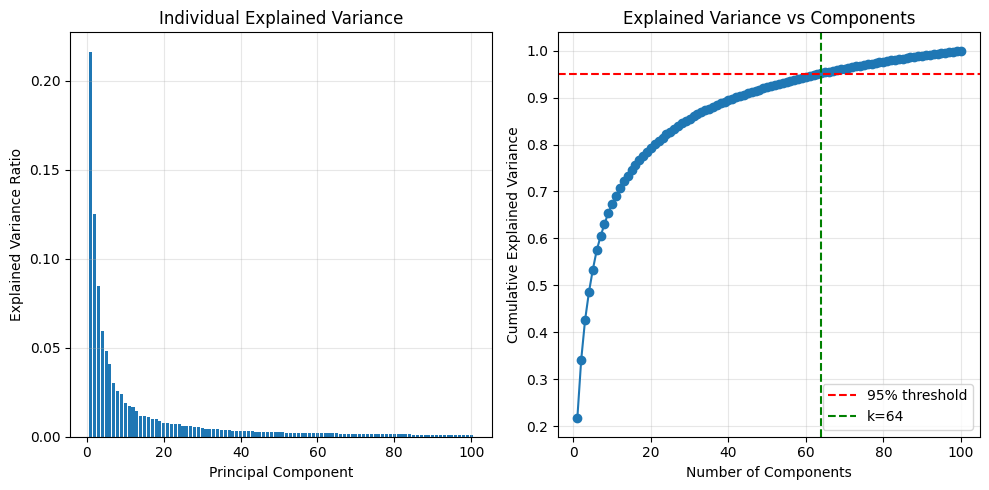

Optimal components: 64 (explains 95.18% variance)


In [7]:
def find_optimal_components(eigenvalues, threshold=0.95, plot=True):
    """
    Find the optimal number of components that explain at least the specified variance threshold.

    Parameters:
    -----------
    eigenvalues : array
        Eigenvalues sorted in descending order
    threshold : float
        Target explained variance threshold (default: 0.95)
    plot : bool
        Whether to visualize the explained variance curve

    Returns:
    --------
    optimal_k : int
        Number of components needed to explain the target variance
    """
    # Calculate explained variance ratio
    total_var = np.sum(eigenvalues)
    explained_var_ratio = eigenvalues / total_var
    cumulative_var_ratio = np.cumsum(explained_var_ratio)

    # Find minimum k that explains threshold% of variance
    optimal_k = np.argmax(cumulative_var_ratio >= threshold) + 1

    if plot:
        plt.figure(figsize=(10, 5))

        # Plot individual explained variance
        plt.subplot(1, 2, 1)
        plt.bar(range(1, len(eigenvalues) + 1), explained_var_ratio)
        plt.xlabel('Principal Component')
        plt.ylabel('Explained Variance Ratio')
        plt.title('Individual Explained Variance')
        plt.grid(alpha=0.3)

        # Plot cumulative explained variance
        plt.subplot(1, 2, 2)
        plt.plot(range(1, len(eigenvalues) + 1), cumulative_var_ratio, marker='o')
        plt.axhline(y=threshold, color='r', linestyle='--',
                   label=f'{threshold*100:.0f}% threshold')
        plt.axvline(x=optimal_k, color='g', linestyle='--',
                   label=f'k={optimal_k}')
        plt.xlabel('Number of Components')
        plt.ylabel('Cumulative Explained Variance')
        plt.title('Explained Variance vs Components')
        plt.legend()
        plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    print(f"Optimal components: {optimal_k} (explains {cumulative_var_ratio[optimal_k-1]*100:.2f}% variance)")
    return optimal_k

# Example usage with PCA results:
projected, eigenvectors, eigenvalues, mean_face, explained_variance = pca(X_train, 100)

optimal_k = find_optimal_components(eigenvalues)

In [8]:
# Function to compute Euclidean distance
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

# Function to compute Manhattan distance
def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))

# Function to compute Cosine distance
def cosine_distance(a, b):
    a_norm = np.linalg.norm(a)
    b_norm = np.linalg.norm(b)
    # To avoid division by zero
    if a_norm == 0.0 or b_norm == 0.0:
        return 1.0
    cosine_sim = np.dot(a, b) / (a_norm * b_norm)
    return 1 - cosine_sim




In [9]:
def pca_methods(X_train, y_train, X_test, y_test, label_dict, n_components=64, metrics=None):
    """
    Compares different distance metrics for classification in PCA space.
    """
    if metrics is None:
        metrics = ['euclidean', 'manhattan', 'cosine']

    # Perform PCA
    projected_train, eigvecs, eigvals, mean_face, _ = pca(X_train, n_components)
    X_test_centered = X_test - mean_face
    projected_test = np.dot(X_test_centered, eigvecs)

    # Dictionary of distance functions
    distance_funcs = {
        'euclidean': euclidean_distance,
        'manhattan': manhattan_distance,
        'cosine': cosine_distance
    }

    accuracies = []

    for metric in metrics:
        dist_func = distance_funcs.get(metric)
        if dist_func is None:
            raise ValueError(f"Unknown metric: {metric}")

        y_pred = []
        for v in projected_test:
            dists = np.array([dist_func(pt, v) for pt in projected_train])
            idx = np.argmin(dists)
            y_pred.append(y_train[idx])
        y_pred = np.array(y_pred)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        print(f"Metric: {metric:10s} | Accuracy: {acc:.4f}")

    plt.bar(metrics, accuracies, color=['C0', 'C1', 'C2', 'C3'][:len(metrics)])
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy comparison for different distance metrics (PCA, k={n_components})")
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    plt.show()


In [10]:
def compare_knn_neighbors(
        X_train, y_train, X_test, y_test,
        label_dict, n_components=64, max_k=10,
        metric='cosine', pca_func=None
    ):
    """
    Compares recognition accuracy for different numbers of neighbors (k) in kNN
    after projection into PCA space.

    :param X_train: training dataset
    :param y_train: training labels
    :param X_test: test dataset
    :param y_test: test labels
    :param label_dict: dictionary mapping human names to IDs
    :param n_components: number of principal components for PCA
    :param max_k: maximum number of neighbors to evaluate
    :param metric: distance metric ('euclidean', 'manhattan', 'cosine')
    :param pca_func: function to compute PCA (e.g., pca_from_scratch)
    """

    # Default PCA function
    if pca_func is None:
        pca_func = pca

    # Project into PCA space
    projected_train, eigvecs, eigvals, mean_face, _ = pca_func(X_train, n_components)
    projected_test = np.dot(X_test - mean_face, eigvecs)

    # Compute distances between samples
    def compute_dist(v, train):
        if metric == 'euclidean':
            return np.linalg.norm(train - v, axis=1)
        elif metric == 'manhattan':
            return np.sum(np.abs(train - v), axis=1)
        elif metric == 'cosine':
            v_norm = np.linalg.norm(v)
            train_norms = np.linalg.norm(train, axis=1)
            dot_products = np.dot(train, v)
            cos_sim = dot_products / (train_norms * v_norm + 1e-10)
            return 1 - cos_sim
        else:
            raise ValueError(f"Unknown metric: {metric}")

    accs = []
    ks = range(1, max_k + 1)

    for k in ks:
        y_pred = []
        for v in projected_test:
            dists = compute_dist(v, projected_train)
            nn_idx = np.argpartition(dists, k - 1)[:k]
            # Majority vote among k nearest neighbors
            votes = y_train[nn_idx]
            label = Counter(votes).most_common(1)[0][0]
            y_pred.append(label)
        y_pred = np.array(y_pred)
        acc = accuracy_score(y_test, y_pred)
        accs.append(acc)
        print(f"k = {k:2d}, accuracy = {acc:.4f}")

    plt.plot(ks, accs, marker='o')
    plt.xlabel("Number of Neighbors (k)")
    plt.ylabel("Classification Accuracy")
    plt.title(f"Effect of k on Accuracy (metric = {metric}, PCA = {n_components})")
    plt.grid(alpha=0.3)
    plt.show()


In [ ]:
compare_knn_neighbors(X_train, y_train, X_test, y_test, label_dict, n_components=optimal_k, max_k=10)

Metric: euclidean  | Accuracy: 0.3500
Metric: manhattan  | Accuracy: 0.3300
Metric: cosine     | Accuracy: 0.3100


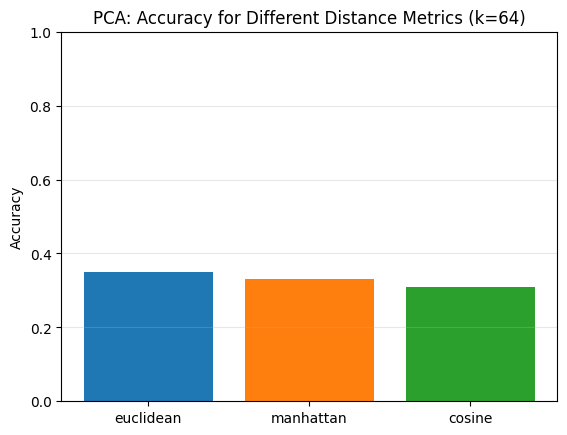

{'euclidean': 0.35, 'manhattan': 0.33, 'cosine': 0.31}

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

def compare_pca_metrics(X_train, y_train, X_test, y_test, n_components=64, metrics=None):
    """
    Compare classification accuracy in PCA space using different distance metrics.

    Args:
        X_train, y_train: Training data and labels
        X_test, y_test: Test data and labels
        n_components: Number of PCA components
        metrics: List of metrics to compare ('euclidean', 'manhattan', 'cosine')

    Returns:
        Dictionary with accuracy for each metric
    """
    if metrics is None:
        metrics = ['euclidean', 'manhattan', 'cosine']

    # Perform PCA
    projected_train, eigvecs, _, mean_face, _ = pca(X_train, n_components)
    projected_test = np.dot(X_test - mean_face, eigvecs)


    dist_funcs = {
        'euclidean': euclidean,
        'manhattan': manhattan,
        'cosine': cosine
    }

    results = {}
    for metric in metrics:
        dist_func = dist_funcs[metric]
        y_pred = []
        for v in projected_test:
            dists = np.array([dist_func(v, t) for t in projected_train])
            idx = np.argmin(dists)
            y_pred.append(y_train[idx])
        acc = accuracy_score(y_test, y_pred)
        results[metric] = acc
        print(f"Metric: {metric:10s} | Accuracy: {acc:.4f}")

    # Plot
    plt.bar(results.keys(), results.values(), color=['C0', 'C1', 'C2'][:len(results)])
    plt.ylabel("Accuracy")
    plt.title(f"PCA: Accuracy for Different Distance Metrics (k={n_components})")
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    return results
compare_pca_metrics(X_train, y_train, X_test, y_test, n_components=optimal_k)

In [1]:
def lda_fit(X, y, n_components=None):
    """
    Computes LDA directions and returns the projection of training data.
    :param X: training samples (n_samples, n_features)
    :param y: class labels (n_samples,)
    :param n_components: desired number of components (up to C-1, where C is the number of classes)
    :return: projected X, eigvecs (matrix of shape n_features × n_components), mean_vectors
    """
    class_labels = np.unique(y)
    n_classes = len(class_labels)
    n_features = X.shape[1]
    if n_components is None:
        n_components = n_classes - 1

    # Overall mean
    overall_mean = np.mean(X, axis=0)

    # Mean of each class
    mean_vectors = []
    for cl in class_labels:
        mean_vectors.append(np.mean(X[y == cl], axis=0))

    # Within-class and between-class scatter matrices
    S_W = np.zeros((n_features, n_features))
    S_B = np.zeros((n_features, n_features))
    for cl, mv in zip(class_labels, mean_vectors):
        Xi = X[y == cl]
        S_W += np.dot((Xi - mv).T, Xi - mv)
        n_cl = Xi.shape[0]
        mean_diff = (mv - overall_mean).reshape(-1, 1)
        S_B += n_cl * np.dot(mean_diff, mean_diff.T)

    # Generalized eigenvalue problem
    eigvals, eigvecs = find_eigens(np.linalg.pinv(S_W).dot(S_B))

    # Sort components by descending eigenvalues
    idxs = np.argsort(np.abs(eigvals))[::-1]
    eigvecs = np.real(eigvecs[:, idxs[:n_components]])  # Keep only the desired number of real components

    # Project training data
    X_lda = np.dot(X, eigvecs)
    return X_lda, eigvecs, mean_vectors, class_labels


def compute_dist(v1, v2, metric='euclidean'):
    if metric == 'euclidean':
        return np.sqrt(np.sum((v1 - v2) ** 2))
    elif metric == 'cosine':
        v1_norm = np.linalg.norm(v1)
        v2_norm = np.linalg.norm(v2)
        return 1 - np.dot(v1, v2) / (v1_norm * v2_norm + 1e-10)
    elif metric == 'manhattan':
        return np.sum(np.abs(v1 - v2))


def lda_predict(X_train_lda, y_train, eigvecs, X_test, metric='euclidean'):
    X_test_lda = np.dot(X_test, eigvecs)
    y_pred = []
    for test in X_test_lda:
        dists = np.array([compute_dist(row, test, metric) for row in X_train_lda])
        min_index = np.argmin(dists)
        y_pred.append(y_train[min_index])
    return y_pred


# LDA after PCA 
X_train_pca, eigvecs_pca, _, _, _ = pca(X_train, n_components=optimal_k)
X_test_pca = np.dot(X_test - np.mean(X_train, axis=0), eigvecs_pca)

X_train_lda, lda_vecs, mean_vectors, class_labels = lda_fit(X_train_pca, y_train)
y_pred = lda_predict(X_train_lda, y_train, lda_vecs, X_test_pca, metric='manhattan')

acc = accuracy_score(y_test, y_pred)
print(f"PCA+LDA accuracy: {acc:.4f}")
# Just LDA
X_train_lda, lda_vecs, mean_vectors, class_labels = lda_fit(X_train, y_train,optimal_k)
y_pred = lda_predict(X_train_lda, y_train, lda_vecs, X_test, metric='manhattan')
acc = accuracy_score(y_test, y_pred)
print(f"LDA accuracy: {acc:.4f}")

NameError: name 'pca' is not defined

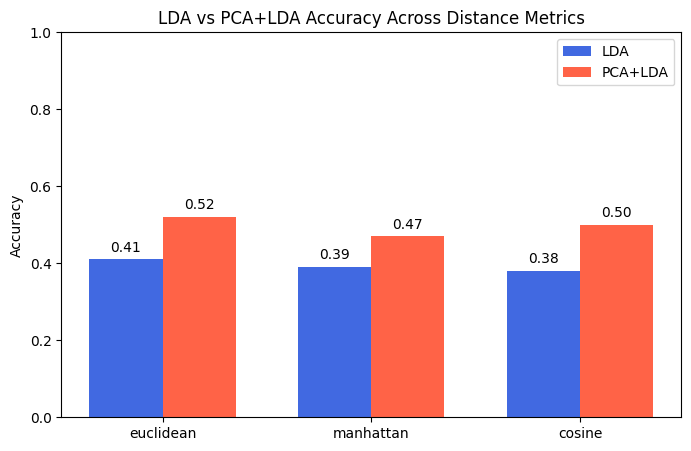

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

def compare_lda_pca_lda_metrics(X_train, y_train, X_test, y_test, n_pca, n_lda):
    metrics = ['euclidean', 'manhattan', 'cosine']
    acc_lda = []
    acc_pca_lda = []

    for metric in metrics:
        # LDA
        X_train_lda, lda_vecs, _, _ = lda_fit(X_train, y_train, n_lda)
        y_pred_lda = lda_predict(X_train_lda, y_train, lda_vecs, X_test, metric=metric)
        acc_lda.append(accuracy_score(y_test, y_pred_lda))

        # PCA + LDA
        X_train_pca, eigvecs_pca, *_ = pca(X_train, n_components=n_pca)
        X_test_pca = np.dot(X_test - np.mean(X_train, axis=0), eigvecs_pca)
        X_train_pca_lda, lda_vecs_pca, _, _ = lda_fit(X_train_pca, y_train, n_lda)
        y_pred_pca_lda = lda_predict(X_train_pca_lda, y_train, lda_vecs_pca, X_test_pca, metric=metric)
        acc_pca_lda.append(accuracy_score(y_test, y_pred_pca_lda))

    # Plotting
    x = np.arange(len(metrics))
    width = 0.35
    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, acc_lda, width, label='LDA', color='royalblue')
    plt.bar(x + width/2, acc_pca_lda, width, label='PCA+LDA', color='tomato')
    plt.xticks(x, metrics)
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    plt.title('LDA vs PCA+LDA Accuracy Across Distance Metrics')
    for i, v in enumerate(acc_lda):
        plt.text(i - width/2, v + 0.02, f'{v:.2f}', ha='center')
    for i, v in enumerate(acc_pca_lda):
        plt.text(i + width/2, v + 0.02, f'{v:.2f}', ha='center')
    plt.legend()
    plt.show()

# Example usage:
n_classes = len(np.unique(y_train))
n_lda = min(n_classes - 1, optimal_k)

compare_lda_pca_lda_metrics(X_train, y_train, X_test, y_test, n_pca=58, n_lda=n_lda)

In [24]:
import numpy as np
from numpy.linalg import norm

def modified_gram_schmidt_qr(X):
    n, k = X.shape
    Q = np.zeros((n, k))
    R = np.zeros((k, k))

    for i in range(k):
        v = X[:, i].copy()
        for j in range(i):
            R[j, i] = np.dot(Q[:, j], v)
            v -= R[j, i] * Q[:, j]
        R[i, i] = norm(v)
        if R[i, i] > 1e-12:
            Q[:, i] = v / R[i, i]
    return Q, R

def power_iteration_block(A, num_vecs, max_iters=100, tol=1e-6):
    n = A.shape[1]
    Q = np.random.randn(n, num_vecs)
    Q, _ = modified_gram_schmidt_qr(Q)

    for _ in range(max_iters):
        Z = A @ Q
        Q_new, _ = modified_gram_schmidt_qr(Z)

        if norm(Q_new - Q) < tol:
            break
        Q = Q_new

    B = Q.T @ A @ Q
    eigvals = np.diag(B)
    return eigvals, Q

def svd_top_k(A, k, max_iters=100):
    m, n = A.shape

    ATA = A.T @ A
    eigvals, V = power_iteration_block(ATA, k, max_iters)

    idx = np.argsort(-np.abs(eigvals))
    eigvals = eigvals[idx]
    V = V[:, idx]
    singular_values = np.sqrt(np.clip(eigvals, 0, None))

    U = np.zeros((m, k))
    for i in range(k):
        if singular_values[i] > 1e-6:
            U[:, i] = A @ V[:, i] / singular_values[i]
        else:
            U[:, i] = 0

    Vt = V.T
    return U, singular_values, Vt
X_train_proc, X_test_proc = preprocess_images(X_train, X_test)
k = 17
U, S, Vt = svd_top_k(X_train_proc, k=k)
X_train_proj = X_train_proc @ Vt[:k].T
X_test_proj = X_test_proc @ Vt[:k].T
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_proj, y_train)
preds = knn.predict(X_test_proj)
accuracy = np.mean(preds == y_test)
print(f"Accuracy: {accuracy:.2%}")



Accuracy: 40.00%


In [25]:
def nmf_from_scratch(X, n_components, max_iter=100, tol=1e-4):
    X = np.maximum(X, 0)
    n_features, n_samples = X.shape

    np.random.seed(42)
    W = np.random.rand(n_features, n_components)
    H = np.random.rand(n_components, n_samples)

    prev_error = np.inf

    for i in range(max_iter):
        H *= (W.T @ X) / (W.T @ W @ H + 1e-10)
        W *= (X @ H.T) / (W @ (H @ H.T) + 1e-10)

        error = np.linalg.norm(X - W @ H, 'fro')
        if abs(prev_error - error) < tol:
            break
        prev_error = error

    return W, H

def project_to_nmf(X_test, W, max_iter=100):
    X_test = np.maximum(X_test, 0)
    n_components = W.shape[1]
    n_samples = X_test.shape[1]

    H_test = np.abs(np.random.rand(n_components, n_samples))

    for _ in range(max_iter):
        H_test *= (W.T @ X_test) / (W.T @ W @ H_test + 1e-10)

    return H_test

# Transpose training data to match NMF assumptions: (features, samples)
V_train = X_train.T 
W_nmf, H_nmf = nmf_from_scratch(V_train, n_components=10)

V_test = X_test.T  
H_test = project_to_nmf(V_test, W_nmf)

# Classification
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(H_nmf.T, y_train)
y_pred = knn.predict(H_test.T)

accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Test Accuracy: 38.00%


In [43]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

def train_cnn(X_train, y_train, X_test, y_test, epochs=10):
    # Підготовка розмірностей (припускаємо, що фото вже одномірні)
    img_dim = int(np.sqrt(X_train.shape[1]))
    X_train_cnn = X_train.reshape(-1, img_dim, img_dim, 1)
    X_test_cnn = X_test.reshape(-1, img_dim, img_dim, 1)

    # Коректуємо мітки до послідовних чисел від 0 до N-1
    le = LabelEncoder()
    le.fit(y_train)
    y_train_enc = le.transform(y_train)
    y_test_enc = le.transform(y_test)
    n_classes = len(le.classes_)

    # One-hot-перетворення
    y_train_cnn = to_categorical(y_train_enc, n_classes)
    y_test_cnn = to_categorical(y_test_enc, n_classes)

    # Побудова моделі
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(img_dim, img_dim, 1)),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        Dense(n_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5, verbose=1),
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
    ]

    history = model.fit(
        X_train_cnn, y_train_cnn,
        validation_data=(X_test_cnn, y_test_cnn),
        epochs=epochs,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )

    # Передбачення та декодування назад у оригінальні мітки
    y_pred = np.argmax(model.predict(X_test_cnn), axis=1)
    y_pred_labels = le.inverse_transform(y_pred)

    return model, y_pred_labels, history
cnn_model, cnn_preds, cnn_history = train_cnn(X_train, y_train, X_test, y_test, epochs=10)
cnn_accuracy = np.mean(cnn_preds == y_test)
print(cnn_accuracy)

Epoch 1/10
31/31 [==============================] - 2s 40ms/step - loss: 2.2003 - accuracy: 0.3541 - val_loss: 8.9489 - val_accuracy: 0.1600 - lr: 0.0010
Epoch 2/10
31/31 [==============================] - 1s 33ms/step - loss: 1.2106 - accuracy: 0.6041 - val_loss: 2.4410 - val_accuracy: 0.3600 - lr: 0.0010
Epoch 3/10
31/31 [==============================] - 1s 34ms/step - loss: 0.8020 - accuracy: 0.7276 - val_loss: 1.4281 - val_accuracy: 0.5800 - lr: 0.0010
Epoch 4/10
31/31 [==============================] - 1s 33ms/step - loss: 0.5814 - accuracy: 0.8194 - val_loss: 1.0425 - val_accuracy: 0.6600 - lr: 0.0010
Epoch 5/10
31/31 [==============================] - 1s 32ms/step - loss: 0.3789 - accuracy: 0.8827 - val_loss: 1.0521 - val_accuracy: 0.6000 - lr: 0.0010
Epoch 6/10
31/31 [==============================] - 1s 34ms/step - loss: 0.2688 - accuracy: 0.9276 - val_loss: 0.9564 - val_accuracy: 0.7100 - lr: 0.0010
Epoch 7/10
31/31 [==============================] - 1s 34ms/step - loss: 0.2

Epoch 1/10
31/31 [==============================] - 2s 39ms/step - loss: 2.3430 - accuracy: 0.3582 - val_loss: 8.0119 - val_accuracy: 0.1800 - lr: 0.0010
Epoch 2/10
31/31 [==============================] - 1s 32ms/step - loss: 1.3394 - accuracy: 0.5704 - val_loss: 2.2745 - val_accuracy: 0.4100 - lr: 0.0010
Epoch 3/10
31/31 [==============================] - 1s 32ms/step - loss: 0.8676 - accuracy: 0.7265 - val_loss: 1.5782 - val_accuracy: 0.4900 - lr: 0.0010
Epoch 4/10
31/31 [==============================] - 1s 32ms/step - loss: 0.6392 - accuracy: 0.7898 - val_loss: 1.3650 - val_accuracy: 0.5600 - lr: 0.0010
Epoch 5/10
31/31 [==============================] - 1s 31ms/step - loss: 0.4348 - accuracy: 0.8755 - val_loss: 1.1094 - val_accuracy: 0.6600 - lr: 0.0010
Epoch 6/10
31/31 [==============================] - 1s 32ms/step - loss: 0.3530 - accuracy: 0.8949 - val_loss: 1.0520 - val_accuracy: 0.6100 - lr: 0.0010
Epoch 7/10
31/31 [==============================] - 1s 32ms/step - loss: 0.2

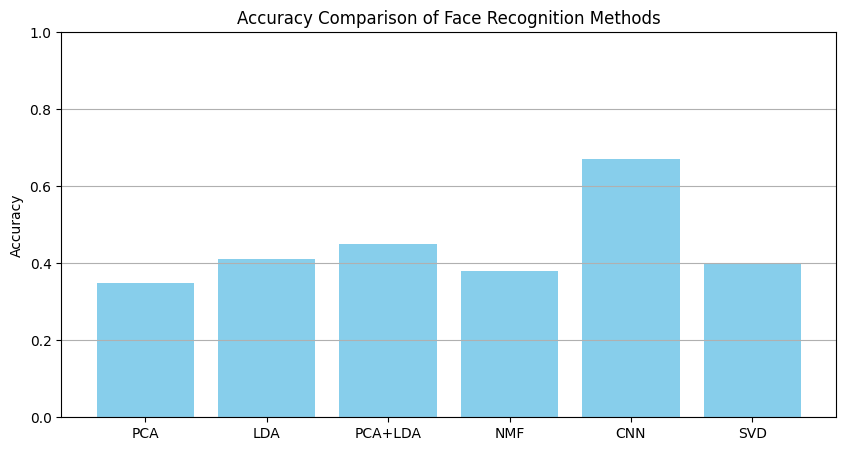

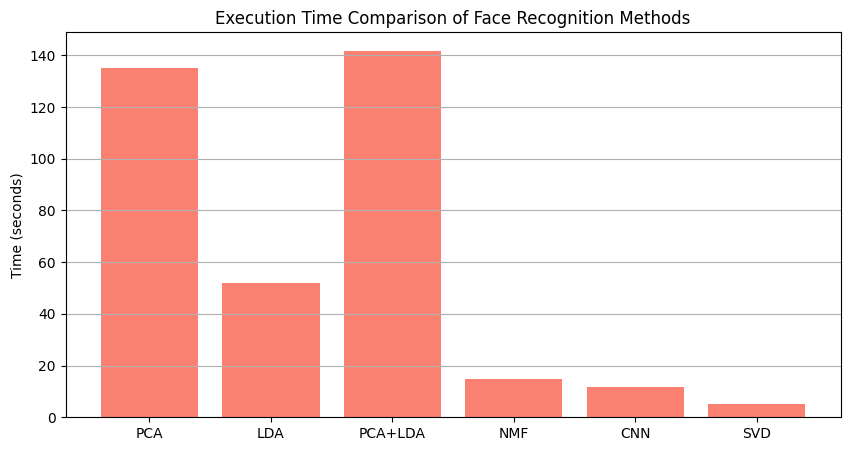

In [52]:
import time
def evaluate_all_methods(X_train, y_train, X_test, y_test):
    """
    Evaluate and compare accuracy of all face recognition methods.

    Args:
        X_train, y_train: Training data and labels
        X_test, y_test: Testing data and labels

    Returns:
        Dictionary with results for all methods
    """
    # --- PCA ---
    time_pca1 = time.time()
    X_train_projected, eigenvectors, eigenvalues, mean_face, explained_variance = pca(X_train, 58)
    X_test_centered = X_test - mean_face
    projected_test = np.dot(X_test_centered, eigenvectors)
    dists = np.linalg.norm(X_train_projected[:, np.newaxis, :] - projected_test[np.newaxis, :, :], axis=2)
    nearest_indices = np.argmin(dists, axis=0)
    nearest_classes = y_train[nearest_indices]
    y_pred = nearest_classes
    accuracy_pca = np.mean(y_pred == y_test)
    time_pca2 = time.time()
    time_pca = time_pca2 - time_pca1
    results['PCA'] = {'accuracy': accuracy_pca, 'time': time_pca}

    # --- LDA (Euclidean) ---
    time_lda1 = time.time()
    n_classes = len(np.unique(y_train))
    n_lda = min(n_classes - 1, 58)
    X_train_lda, lda_vecs, _, _ = lda_fit(X_train, y_train, n_lda)
    y_pred_lda = lda_predict(X_train_lda, y_train, lda_vecs, X_test, metric='euclidean')
    accuracy_lda_euclidean = accuracy_score(y_test, y_pred_lda)
    time_lda2 = time.time()
    time_lda_euclidean = time_lda2 - time_lda1
    results['LDA (euclidean)'] = {'accuracy': accuracy_lda_euclidean, 'time': time_lda_euclidean}

    # --- PCA+LDA (Euclidean) ---
    time_pca_lda1 = time.time()
    X_train_pca, eigvecs_pca, *_ = pca(X_train, n_components=58)
    X_test_pca = np.dot(X_test - np.mean(X_train, axis=0), eigvecs_pca)
    X_train_pca_lda, lda_vecs_pca, _, _ = lda_fit(X_train_pca, y_train, n_lda)
    y_pred_pca_lda = lda_predict(X_train_pca_lda, y_train, lda_vecs_pca, X_test_pca, metric='euclidean')
    accuracy_pca_lda_euclidean = accuracy_score(y_test, y_pred_pca_lda)
    time_pca_lda2 = time.time()
    time_pca_lda_euclidean = time_pca_lda2 - time_pca_lda1
    results['PCA+LDA (euclidean)'] = {'accuracy': accuracy_pca_lda_euclidean, 'time': time_pca_lda_euclidean}


    time_nmf1=time.time()
    V_train = X_train.T 
    W_nmf, H_nmf = nmf_from_scratch(V_train, n_components=10)
    V_test = X_test.T  
    H_test = project_to_nmf(V_test, W_nmf)
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(H_nmf.T, y_train)
    y_pred = knn.predict(H_test.T)
    accuracy_nmf = np.mean(y_pred == y_test)
    time_nmf2=time.time()
    time_nmf=time_nmf2-time_nmf1
    time_cnn1=time.time()
    cnn_model, cnn_preds, cnn_history = train_cnn(X_train, y_train, X_test, y_test, epochs=10)
    cnn_accuracy = np.mean(cnn_preds == y_test)
    time_cnn2=time.time()
    time_cnn=time_cnn2-time_cnn1
    time_svd1=time.time()
    X_train_proc, X_test_proc = preprocess_images(X_train, X_test)
    k = 17
    U, S, Vt = svd_top_k(X_train_proc, k=k)
    X_train_proj = X_train_proc @ Vt[:k].T
    X_test_proj = X_test_proc @ Vt[:k].T
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_proj, y_train)
    preds = knn.predict(X_test_proj)
    accuracy_svd = np.mean(preds == y_test)
    time_svd2=time.time()
    time_svd=time_svd2-time_svd1
    return {
    'PCA': {'accuracy': accuracy_pca, 'time': time_pca},
    'LDA': {'accuracy': accuracy_lda_euclidean, 'time': time_lda_euclidean},
    'PCA+LDA': {'accuracy': accuracy_pca_lda_euclidean, 'time': time_pca_lda_euclidean},
    'NMF': {'accuracy': accuracy_nmf, 'time': time_nmf},
    'CNN': {'accuracy': cnn_accuracy, 'time': time_cnn},
    'SVD': {'accuracy': accuracy_svd, 'time': time_svd}
}

results = evaluate_all_methods(X_train, y_train, X_test, y_test)
methods = list(results.keys())
accuracies = [results[m]['accuracy'] for m in methods]
times = [results[m]['time'] for m in methods]

# Accuracy plot
plt.figure(figsize=(10, 5))
plt.bar(methods, accuracies, color='skyblue')
plt.title('Accuracy Comparison of Face Recognition Methods')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

# Time plot
plt.figure(figsize=(10, 5))
plt.bar(methods, times, color='salmon')
plt.title('Execution Time Comparison of Face Recognition Methods')
plt.ylabel('Time (seconds)')
plt.grid(axis='y')
plt.show()


In [61]:
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def prepare_resnet_images(X):
    # X shape: (n_samples, 4096) for 64x64 images
    n = X.shape[0]
    imgs = X.reshape(n, 64, 64)
    imgs_rgb = np.stack([imgs]*3, axis=-1)  # (n, 64, 64, 3)
    imgs_resized = np.zeros((n, 224, 224, 3), dtype='float32')
    for i in range(n):
        img = array_to_img(imgs_rgb[i])
        img = img.resize((224, 224))
        imgs_resized[i] = img_to_array(img)
    return preprocess_input(imgs_resized)
res_time=time.time()
# Prepare images
X_train_resnet = prepare_resnet_images(X_train)
X_test_resnet = prepare_resnet_images(X_test)

# Load ResNet50 without top layer
resnet = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224,224,3))

# Extract features
features_train = resnet.predict(X_train_resnet, verbose=1)
features_test = resnet.predict(X_test_resnet, verbose=1)

# Classify with k-NN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(features_train, y_train)
y_pred = knn.predict(features_test)
res2_time = time.time()
resnet_time = res2_time - res_time
resnet_accuracy = accuracy_score(y_test, y_pred)
print(f"ResNet feature + kNN accuracy: {resnet_accuracy:.4f}")

4/4 [==============================] - 3s 595ms/step
ResNet feature + kNN accuracy: 0.6500


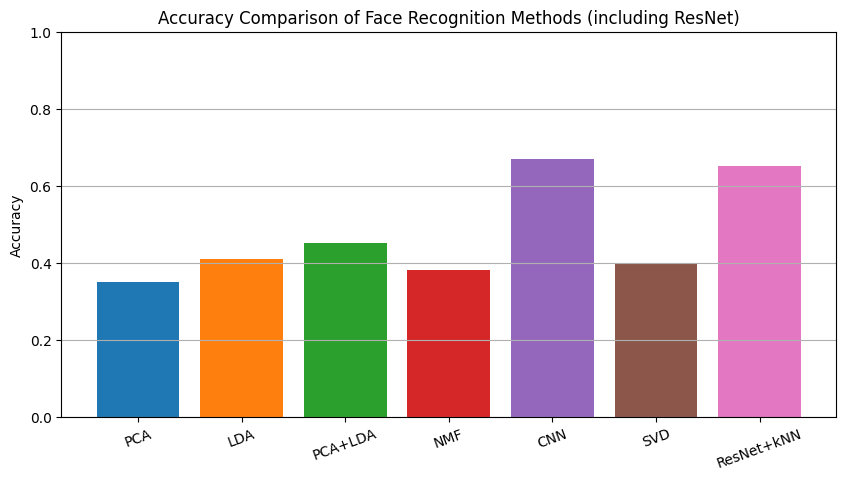

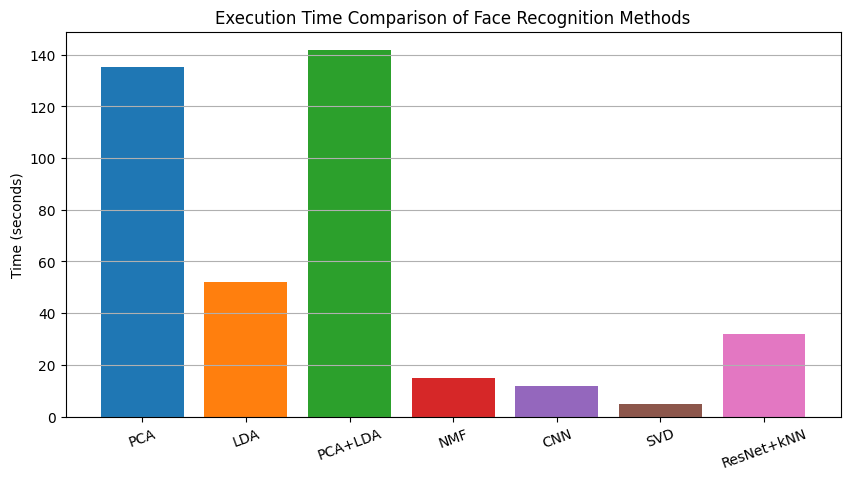

In [66]:
import matplotlib.pyplot as plt

# Add ResNet result to your results dictionary
results['ResNet+kNN'] = {'accuracy': resnet_accuracy, 'time': resnet_time}  # Time can be added if measured

# Prepare data for plotting
methods = list(results.keys())
accuracies = [results[m]['accuracy'] for m in methods]
times = [results[m]['time'] for m in methods]


import matplotlib.pyplot as plt

# Define a color for each method
color_map = {
    'PCA': '#1f77b4',
    'LDA': '#ff7f0e',
    'PCA+LDA': '#2ca02c',
    'NMF': '#d62728',
    'CNN': '#9467bd',
    'SVD': '#8c564b',
    'ResNet+kNN': '#e377c2'
}
# Fallback color if method not in map
colors = [color_map.get(m, '#7f7f7f') for m in methods]

plt.figure(figsize=(10, 5))
plt.bar(methods, accuracies, color=colors)
plt.title('Accuracy Comparison of Face Recognition Methods (including ResNet)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(methods, times, color=colors)
plt.title('Execution Time Comparison of Face Recognition Methods')
plt.ylabel('Time (seconds)')
plt.grid(axis='y')
plt.xticks(rotation=20)
plt.show()